# Analyzing a checkpoint of a model run

In [1]:
from pathlib import Path
from typing import Any

import equinox as eqx
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.colors
import matplotlib.pyplot as plt
import numpy as np
import optax
import scienceplots  # noqa: F401
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.signal import savgol_filter

In [2]:
# set scienceplots style and matplotlib settings
plt.style.use(["science", "bright", "no-latex"])

new_rcParams = {
    "image.cmap": "inferno",
    "font.family": "serif",
    "figure.dpi": 300,
    "font.size": 7,
    "xtick.direction": "out",
    "ytick.direction": "out",
}
plt.rcParams.update(new_rcParams)

## Defining generator and critic class

In [3]:
class GeneratorDisksNIR(eqx.Module):
    """WGAN generator for monochromatic NIR disk images with upsampling.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer, producing a 3D image (Channel, Y, X indexing) cube from an
        input 1D latent vector of given `size_in`.
    - `size_in`: Size of the latent 'noise' input vector to the first layer.
    """

    layers: tuple[Any, ...]  # Different callable layers.
    size_in: int = eqx.field(static=True)  # Size of input latent vector.

    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        key, subkey1, subkey2, subkey3, subkey4, subkey5 = jr.split(key, 6)

        self.size_in = 100
        self.layers = (
            eqx.nn.Linear(
                self.size_in, 256 * 16 * 16, use_bias=True, key=subkey1
            ),  # Fully connected from shape (100,) to (256 * 16 * 16,).
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.reshape(x, shape=(256, 16, 16))
            ),  # Reshape to 256 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    2,
                    axis=2,
                )
            ),  # Upsample to 256 x 32 x 32.
            eqx.nn.Conv2d(
                in_channels=256,
                out_channels=128,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="REFLECT",
                use_bias=True,
                key=subkey2,
            ),  # Regular convolution to 128 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    2,
                    axis=2,
                )
            ),  # Upsample to 128 x 64 x 64.
            eqx.nn.Conv2d(
                in_channels=128,
                out_channels=64,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="REFLECT",
                use_bias=True,
                key=subkey3,
            ),  # Regular convolution to 64 x 64 x 64.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(
                lambda x: jnp.repeat(
                    jnp.repeat(x, repeats=2, axis=1),
                    repeats=2,
                    axis=2,
                )
            ),  # Upsample to 64 x 128 x 128.
            eqx.nn.Conv2d(
                in_channels=64,
                out_channels=32,
                kernel_size=(3, 3),
                stride=(1, 1),
                padding="SAME",
                padding_mode="REFLECT",
                use_bias=True,
                key=subkey4,
            ),  # Regular convolution to 32 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Conv2d(
                in_channels=32,
                out_channels=1,
                kernel_size=(5, 5),
                stride=(1, 1),
                padding="SAME",
                padding_mode="REFLECT",
                use_bias=True,
                key=subkey5,
            ),  # Final regular convolution to 1 x 128 x 128.
            eqx.nn.Lambda(
                lambda x: jnp.tanh(x)
            ),  # Final activation to map to signed unit interval [-1, 1].
        )
        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State, *, key: jax.Array
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the generator neural network.

        **Arguments**

        - `x`: 1D input vector.

        - `state`: The current state of the generator.

        - `key`: A JAX PRNG key meant for calling stochastic layers.

        **Returns**

        A 3D image (Channel, Y, X indexing) cube as a JAX array and the updated
        state of the generator.
        """
        for layer in self.layers:
            if isinstance(layer, eqx.nn.StatefulLayer):
                x, state = layer(x, state)
            else:
                x = layer(x)
        return x, state


class CriticDisksNIR(eqx.Module):
    """WGAN critic for monochromatic NIR disk images. Spectrally normalized to
    maintain 1-Lipschitz continuity.

    **Attributes**

    - `layers`: Tuple containing the different neural network layers. The only
        requirement is that each layer should just be callable using the output of the
        preceding layer. The first layer needs to be able to accept a 3D image (Channel,
        Y, X, indexing) cube.
    """

    layers: tuple[Any, ...]  # Different callable layers.

    def __init__(self, key: jax.Array) -> None:
        """**Arguments**

        - `key`: JAX PRNG key to initialise the model.
        """
        (
            key,
            subkey1,
            subkey2,
            subkey3,
            subkey4,
            subkey5,
            subkey6,
            subkey7,
            subkey8,
        ) = jr.split(key, 9)

        self.layers = (
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=1,
                    out_channels=32,
                    kernel_size=(5, 5),
                    stride=(1, 1),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey1,
                ),
                weight_name="weight",
                num_power_iterations=2,
                key=subkey2,
            ),  # Regular convolution to 32 x 128 x 128 (input is 1 x 128 x 128).
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=32,
                    out_channels=64,
                    kernel_size=(3, 3),
                    stride=(2, 2),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey1,
                ),
                weight_name="weight",
                num_power_iterations=2,
                key=subkey2,
            ),  # Regular convolution to 64 x 64 x 64.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=64,
                    out_channels=128,
                    kernel_size=(3, 3),
                    stride=(2, 2),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey3,
                ),
                weight_name="weight",
                num_power_iterations=2,
                key=subkey4,
            ),  # Regular convolution to 128 x 32 x 32.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.SpectralNorm(
                eqx.nn.Conv2d(
                    in_channels=128,
                    out_channels=256,
                    kernel_size=(3, 3),
                    stride=(2, 2),
                    padding="SAME",
                    padding_mode="ZEROS",
                    use_bias=True,
                    key=subkey5,
                ),
                weight_name="weight",
                num_power_iterations=2,
                key=subkey6,
            ),  # Regular convolution to 256 x 16 x 16.
            eqx.nn.Lambda(
                lambda x: jax.nn.leaky_relu(x, negative_slope=0.1)
            ),  # Activation.
            eqx.nn.Lambda(lambda x: jnp.ravel(x)),  # Ravel to shape (256 * 16 * 16,).
            eqx.nn.SpectralNorm(
                eqx.nn.Linear(256 * 16 * 16, 1, use_bias=True, key=subkey7),
                weight_name="weight",
                num_power_iterations=2,
                key=subkey8,
            ),  # Dense map to scalar of shape (1,) (no further activation needed).
        )

        return

    def __call__(
        self, x: jax.Array, state: eqx.nn.State, *, key: jax.Array
    ) -> tuple[jax.Array, eqx.nn.State]:
        """Feed-forward pass through the neural network.

        **Arguments**

        - `x`: A 3D image (Channel, Y, X indexing) cube array.

        - `state`: The current state of the critic.

        - `key`: A JAX PRNG key meant for calling stochastic layers.

        **Returns**

        A shape (1,) scalar meant to represent the WGAN critic output and the updated
        state of the critic.
        """
        for layer in self.layers:
            if isinstance(layer, eqx.nn.StatefulLayer):
                x, state = layer(x, state)
            else:
                x = layer(x)
        return x, state

## Load in model and optimizer states from checkpoints

In [4]:
# Master PRNG key
master_key = jr.key(232387986534)

# Initialize the generator and critic
master_key, subkey1, subkey2, subkey3, subkey4 = jr.split(master_key, 5)
gen, gen_state = eqx.nn.make_with_state(GeneratorDisksNIR)(key=subkey1)
crit, crit_state = eqx.nn.make_with_state(CriticDisksNIR)(key=subkey2)

# Split generator and critic into desired trainable vs. non-trainable components.
gen_params, gen_static = eqx.partition(gen, filter_spec=eqx.is_array)
crit_params, crit_static = eqx.partition(crit, filter_spec=eqx.is_array)

# Read in from disk.
checkpoint_dir = Path(
    "/home/toond/Documents/phd/paper_iras08_time_series/wgan_training/"
    "run_NIR_disks_128x128_default/output/checkpoint_final/"
)
with open(checkpoint_dir / "gen_params.eqx", "rb") as f:
    gen_params = eqx.tree_deserialise_leaves(f, gen_params)
with open(checkpoint_dir / "gen_state.eqx", "rb") as f:
    gen_state = eqx.tree_deserialise_leaves(f, gen_state)
with open(checkpoint_dir / "crit_params.eqx", "rb") as f:
    crit_params = eqx.tree_deserialise_leaves(f, crit_params)
with open(checkpoint_dir / "crit_params.eqx", "rb") as f:
    crit_params = eqx.tree_deserialise_leaves(f, crit_params)

# Set the control logic for the optimizers.
opt_gen = optax.adam(learning_rate=2e-5, b1=0.0, b2=0.9)
opt_crit = optax.adam(learning_rate=1e-4, b1=0.0, b2=0.9)

# Initialize the generator and critic optimizer states. Note we only want
# to select out the relevant parts to be optimized.
opt_gen_state = opt_gen.init(gen_params)
opt_crit_state = opt_crit.init(crit_params)

# Read in from disk.
with open(checkpoint_dir / "opt_gen_state.eqx", "rb") as f:
    opt_gen_state = eqx.tree_deserialise_leaves(f, opt_gen_state)
with open(checkpoint_dir / "opt_crit_state.eqx", "rb") as f:
    opt_crit_state = eqx.tree_deserialise_leaves(f, opt_crit_state)

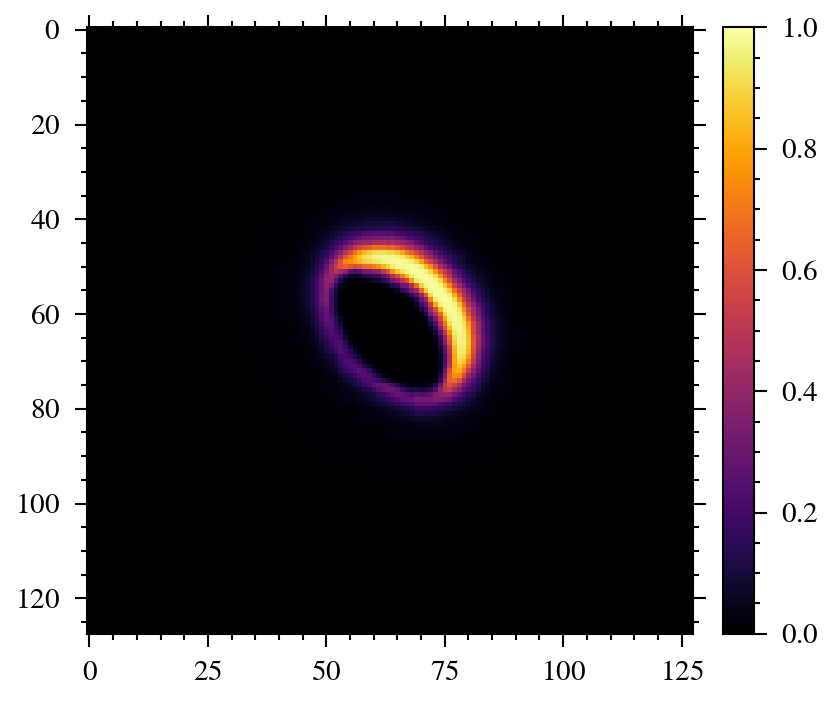

In [5]:
# Check whether generator does indeed make reasonable images.
gen = eqx.combine(gen_params, gen_static)
img, gen_state = gen(jr.normal(jr.key(11200), shape=(100,)), gen_state, key=subkey4)
img = (img[0, :, :] + 1) / 2

fig, ax = plt.subplots(1, 1)
norm = matplotlib.colors.PowerNorm(1.0, vmin=0, vmax=1)
imsh = ax.imshow(img, cmap="inferno", norm=norm)
divider = make_axes_locatable(ax)
cax = divider.append_axes("right", size="5%", pad=0.1)
fig.colorbar(imsh, cax=cax)
plt.show()

## Load in the loss values throughout training

In [6]:
with open(checkpoint_dir / "wasserstein_est.npy", "rb") as f:
    w_est = np.load(f)

In [7]:
%matplotlib widget

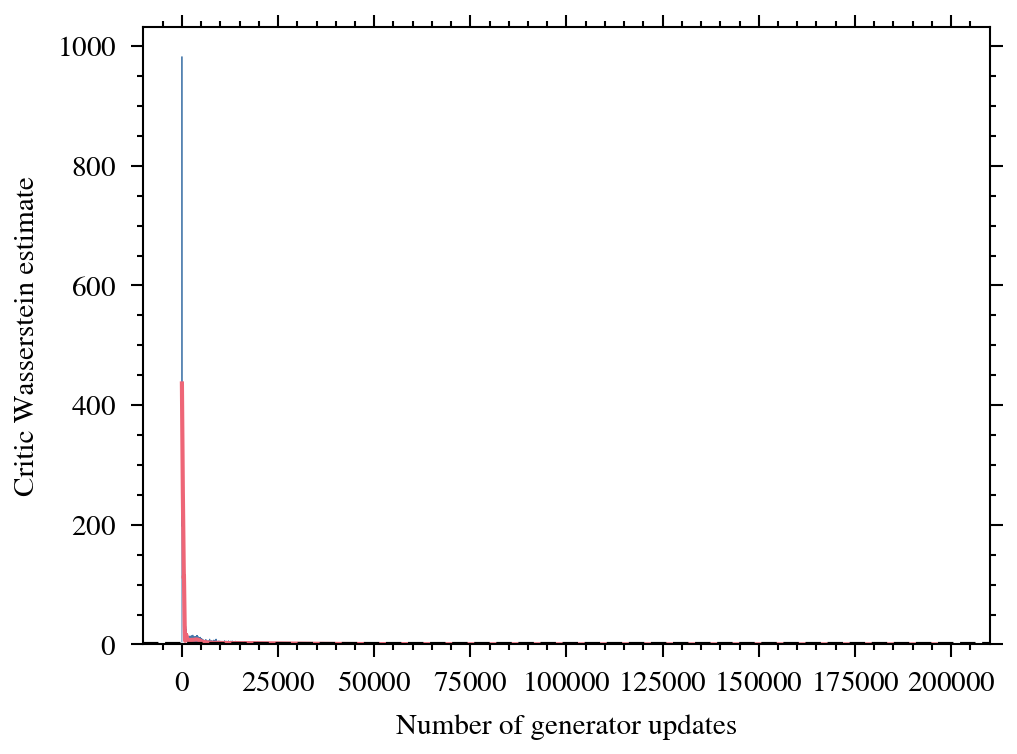

In [8]:
# Filter Wasserstein loss curve before plotting.
w_est_filtered = np.array(savgol_filter(w_est, 1001, 2))

# Make plots.
fig, ax = plt.subplots(1, 1)
ax.plot(range(w_est.size), w_est, lw=0.2)
ax.plot(range(w_est_filtered.size), w_est_filtered)
ax.set_ylabel("Critic Wasserstein estimate")
ax.set_xlabel("Number of generator updates")
ax.set_ylim(0)
ax.axhline(y=0, ls="--", c="k", lw=1.0)
plt.tight_layout()
plt.show()

/tmp/ipykernel_373588/2922718967.py:8: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0)


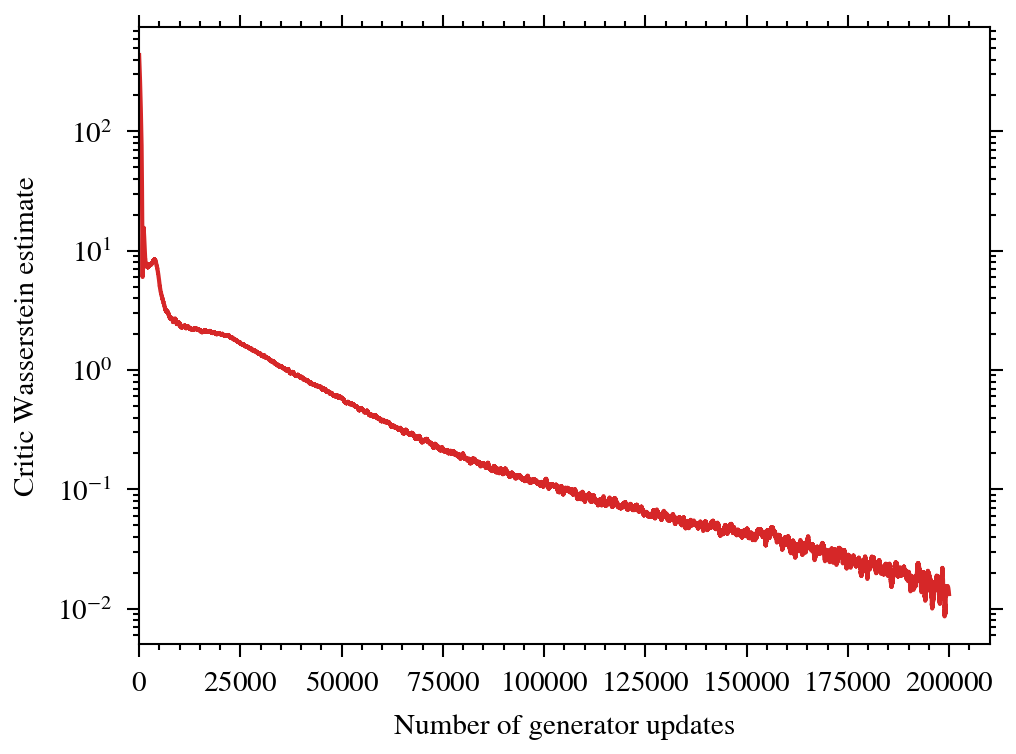

In [9]:
# Make plots.
fig, ax = plt.subplots(1, 1)
ax.plot(range(w_est_filtered.size), w_est_filtered, color="tab:red")
ax.set_ylabel("Critic Wasserstein estimate")
ax.set_xlabel("Number of generator updates")
ax.set_yscale("log")
ax.set_xlim(0)
ax.set_ylim(0)
ax.axhline(y=0, ls="--", c="k", lw=1.0)
plt.tight_layout()
plt.show()